<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/regression_with_regularization/LinearRegressionWithPyTorchNNLayers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install hiddenlayer

In [2]:
import torch
import hiddenlayer as hl
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import sklearn

In [3]:
!pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [4]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()


In [5]:
path = kagglehub.competition_download('bike-sharing-demand')

100%|██████████| 189k/189k [00:00<00:00, 43.9MB/s]

Extracting files...


In [6]:
path

'/root/.cache/kagglehub/competitions/bike-sharing-demand'

In [7]:
import os

dataset_path = '/root/.cache/kagglehub/competitions/bike-sharing-demand'
print(f"Contents of {dataset_path}:")
!ls -lh {dataset_path}

Contents of /root/.cache/kagglehub/competitions/bike-sharing-demand:
total 1.1M
-rw-r--r-- 1 root root 140K Feb 16 17:04 sampleSubmission.csv
-rw-r--r-- 1 root root 317K Feb 16 17:04 test.csv
-rw-r--r-- 1 root root 634K Feb 16 17:04 train.csv


In [8]:
data_path = os.path.join(dataset_path, 'train.csv')
data = pd.read_csv(data_path)

print("Sample Submission DataFrame Head:")
print(data.head())

print("\nSample Submission DataFrame Info:")
data.info()


data.shape



Sample Submission DataFrame Head:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Sample Submission DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  


(10886, 12)

In [9]:
# Convert 'datetime' column to datetime objects
data['datetime'] = pd.to_datetime(data['datetime'])

# Get the minimum and maximum datetime
min_datetime = data['datetime'].min()
max_datetime = data['datetime'].max()

print(f"Minimum datetime: {min_datetime}")
print(f"Maximum datetime: {max_datetime}")

Minimum datetime: 2011-01-01 00:00:00
Maximum datetime: 2012-12-19 23:00:00


In [10]:
data['year'] = data['datetime'].dt.year
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011


Text(0.5, 1.0, 'Number of bikes renter per season')

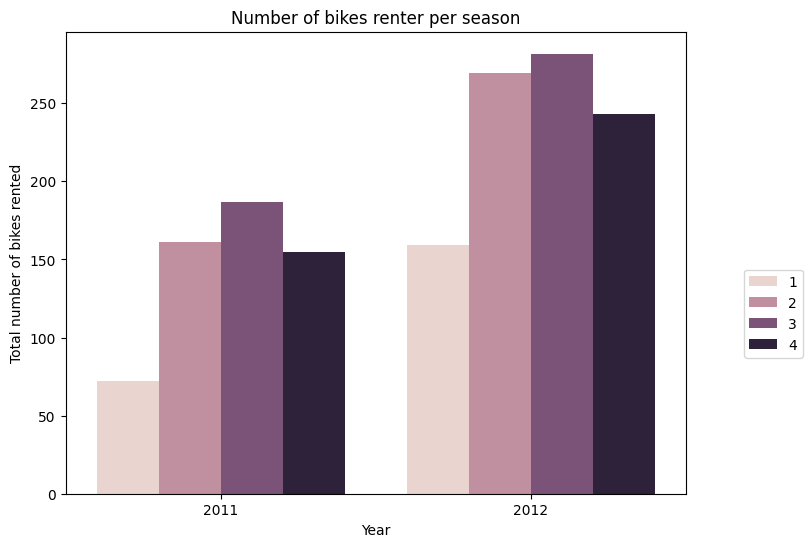

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x='year', y='count', hue='season', data=data, errorbar=None)

plt.legend(loc = 'upper right', bbox_to_anchor= (1.2,0.5))

plt.xlabel('Year')

plt.ylabel('Total number of bikes rented')

plt.title('Number of bikes renter per season')

In [12]:
season_mapping = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter' # Assuming 4 is Winter based on common season numbering
}
data['seasonName'] = data['season'].map(season_mapping)

print(data[['season', 'seasonName']].head())

   season seasonName
0       1     Spring
1       1     Spring
2       1     Spring
3       1     Spring
4       1     Spring


In [13]:
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,seasonName
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,Spring
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,Spring
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,Spring
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,Spring
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,Spring


In [51]:
dataWithSeasonHotEncoded = pd.get_dummies(data, columns=['seasonName'])

dataWithSeasonHotEncoded.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,seasonName_Fall,seasonName_Spring,seasonName_Summer,seasonName_Winter
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,False,True,False,False
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,False,True,False,False
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,False,True,False,False
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,False,True,False,False
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,False,True,False,False


In [64]:
columns = ['holiday','workingday','weather', 'temp','atemp','seasonName_Spring','seasonName_Summer','seasonName_Fall','seasonName_Winter']

features = dataWithSeasonHotEncoded[columns]

features.iloc[10347]

,10347
holiday,0
workingday,1
weather,1
temp,17.22
atemp,21.21
seasonName_Spring,False
seasonName_Summer,False
seasonName_Fall,False
seasonName_Winter,True


In [16]:
target = dataWithSeasonHotEncoded[['count']]

In [63]:
target.iloc[10347]

,10347
count,278


In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [66]:
x_train.head()
y_test.iloc[1277]

,660
count,160


In [54]:
x_test.head()

,holiday,workingday,weather,temp,atemp,seasonName_Spring,seasonName_Summer,seasonName_Fall,seasonName_Winter
7677,0,0,1,18.04,21.970,False,True,False,False
8767,0,1,3,31.16,36.365,False,False,True,False
7477,0,1,1,20.50,24.240,False,True,False,False
3637,0,1,2,27.06,31.060,False,False,True,False
9337,0,1,1,25.42,30.305,False,False,True,False


In [21]:
x_train_tensor = torch.from_numpy(x_train.values.astype(float))
x_test_tensor = torch.from_numpy(x_test.values.astype(float))
y_train_tensor = torch.from_numpy(y_train.values.astype(float))
y_test_tensor = torch.from_numpy(y_test.values.astype(float))

In [22]:
x_train_tensor.shape

torch.Size([8708, 9])

In [23]:
import torch.utils.data as data_utils

In [24]:
train_data = data_utils.TensorDataset(x_train_tensor, y_train_tensor)
train_data

In [25]:
train_loader = data_utils.DataLoader(train_data, batch_size=100, shuffle=True)

In [26]:
len(train_loader)

88

In [27]:
features_batch, target_batch = next(iter(train_loader))

In [28]:
features_batch.shape

torch.Size([100, 9])

In [29]:
inp = x_train_tensor.shape[1]

In [30]:
out  = 1

In [31]:
hid  = 10

In [32]:
loss_fn = torch.nn.MSELoss()

In [33]:
model = torch.nn.Sequential(torch.nn.Linear(inp,hid), torch.nn.ReLU(), torch.nn.Linear(hid, out))

In [34]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [81]:
total_step = len(train_loader)
y_train.head()
epochs = 5000
for epoch in range(epochs + 1):
    for i, (features_batch, target_batch) in enumerate(train_loader):

        # Forward pass
        output = model(features_batch.float())

        # Calculate the loss
        loss = loss_fn(output, target_batch.float())

        # Zero the gradients
        optimizer.zero_grad()

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    if (epoch) % 2 == 0:
        print('Epoch [{}/{}], Step[{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, i+1, total_step, loss.item()))

print("Training complete!")

Epoch [1/5000], Step[88/88], Loss: 12778.0010
Epoch [3/5000], Step[88/88], Loss: 22537.6211
Epoch [5/5000], Step[88/88], Loss: 39351.9727
Epoch [7/5000], Step[88/88], Loss: 61024.8945
Epoch [9/5000], Step[88/88], Loss: 22566.7578
Epoch [11/5000], Step[88/88], Loss: 45457.1328
Epoch [13/5000], Step[88/88], Loss: 64551.4805
Epoch [15/5000], Step[88/88], Loss: 22975.4902
Epoch [17/5000], Step[88/88], Loss: 17330.2656
Epoch [19/5000], Step[88/88], Loss: 48496.8945
Epoch [21/5000], Step[88/88], Loss: 18252.2617
Epoch [23/5000], Step[88/88], Loss: 14319.3379
Epoch [25/5000], Step[88/88], Loss: 26068.8398
Epoch [27/5000], Step[88/88], Loss: 54368.8633
Epoch [29/5000], Step[88/88], Loss: 6739.5796
Epoch [31/5000], Step[88/88], Loss: 32828.7656
Epoch [33/5000], Step[88/88], Loss: 18594.9434
Epoch [35/5000], Step[88/88], Loss: 7043.3564
Epoch [37/5000], Step[88/88], Loss: 53632.7422
Epoch [39/5000], Step[88/88], Loss: 15339.5908
Epoch [41/5000], Step[88/88], Loss: 18450.2715
Epoch [43/5000], Ste

In [82]:
model.eval()

with torch.no_grad():
    y_pred = model(x_test_tensor.float())

In [83]:
sample = x_test.iloc[45]
sample

,4642
holiday,0
workingday,0
weather,1
temp,18.04
atemp,21.97
seasonName_Spring,False
seasonName_Summer,False
seasonName_Fall,False
seasonName_Winter,True


In [84]:
sample_tensor = torch.tensor(sample.values.astype(float))
sample_tensor

tensor([ 0.0000,  0.0000,  1.0000, 18.0400, 21.9700,  0.0000,  0.0000,  0.0000,
         1.0000], dtype=torch.float64)

In [86]:
with torch.no_grad():
  y_pred = model(sample_tensor.float())

print("Predicted count:", (y_pred.item()))
print("Actual count:", (y_test.iloc[45]))

Predicted count: 233.55064392089844
Actual count: count    346
Name: 4642, dtype: int64


In [87]:
with torch.no_grad():
    y_pred = model(x_test_tensor.float())

In [88]:
y_pred_np = y_pred.detach().numpy()

y_pred_np.shape

(2178, 1)

In [89]:
y_test.values.shape

(2178, 1)

In [90]:
compare_df = pd.DataFrame({'actual' : np.squeeze(y_test.values), 'predicted' : np.squeeze(y_pred)})
compare_df.sample(20)

,actual,predicted
1509,3,127.070885
1271,376,276.457275
2076,17,67.367554
190,67,253.708252
721,287,259.661987
2129,142,309.435638
3,192,189.436310
2170,118,169.117798
2115,153,154.237946
9,5,17.195040


In [92]:
sklearn.metrics.r2_score(y_test, y_pred)
#

0.2153293331134194